In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': 'white'})

# ── MOCK DATA
np.random.seed(42)
comp = pd.DataFrame({
    'company_id': range(1, 101),
    'company_name': [f"Company_{i}" for i in range(1, 101)],
    'sector': np.random.choice(['IT','Banking','FMCG','Pharma','Auto','Energy'], 100),
    'roe_percentage': np.random.uniform(5, 40, 100)
})
pl = pd.DataFrame({
    'company_id': np.repeat(range(1, 101), 10),
    'year_id': np.tile(range(2014, 2024), 100),
    'sales': np.random.uniform(500, 50000, 1000),
    'net_profit': np.random.uniform(50, 8000, 1000),
    'opm_pct': np.random.uniform(5, 35, 1000),
    'dividend_payout_pct': np.random.uniform(0, 60, 1000),
})
bs = pd.DataFrame({
    'company_id': np.repeat(range(1, 101), 10),
    'year_id': np.tile(range(2014, 2024), 100),
    'debt_to_equity': np.random.uniform(0, 3, 1000),
})
cf = pd.DataFrame({
    'company_id': np.repeat(range(1, 101), 10),
    'year_id': np.tile(range(2014, 2024), 100),
    'operating_activity': np.random.uniform(-500, 12000, 1000),
})
ana = pd.DataFrame({
    'company_id': np.repeat(range(1, 101), 3),
    'metric': np.tile(['compounded_sales_growth'], 300),
    'period_label': np.tile(['3Y', '5Y', '10Y'], 100),
    'value_pct': np.random.uniform(-5, 30, 300),
})

print("✅ Data loaded — ready for clustering!")

✅ Data loaded — ready for clustering!


In [12]:
# Step 1 — Build feature vector per company
avg_opm = pl.groupby('company_id')['opm_pct'].mean().reset_index().rename(columns={'opm_pct': 'avg_opm'})
avg_dividend = pl.groupby('company_id')['dividend_payout_pct'].mean().reset_index().rename(columns={'dividend_payout_pct': 'avg_dividend'})
avg_de = bs.groupby('company_id')['debt_to_equity'].mean().reset_index().rename(columns={'debt_to_equity': 'avg_de'})

cf_pl = cf.merge(pl[['company_id', 'year_id', 'net_profit']], on=['company_id', 'year_id'], how='left')
cf_pl['ccr'] = cf_pl['operating_activity'] / cf_pl['net_profit'].replace(0, np.nan)
avg_ccr = cf_pl.groupby('company_id')['ccr'].mean().reset_index().rename(columns={'ccr': 'avg_ccr'})

cagr3 = ana[(ana['metric'] == 'compounded_sales_growth') & (ana['period_label'] == '3Y')]
cagr3 = cagr3[['company_id', 'value_pct']].rename(columns={'value_pct': 'avg_growth_3y'})

features = comp[['company_id', 'company_name', 'sector', 'roe_percentage']].copy()
features = features.merge(avg_opm, on='company_id', how='left')
features = features.merge(avg_dividend, on='company_id', how='left')
features = features.merge(avg_de, on='company_id', how='left')
features = features.merge(avg_ccr, on='company_id', how='left')
features = features.merge(cagr3, on='company_id', how='left')
features = features.fillna(features.median(numeric_only=True))

feature_cols = ['avg_opm', 'roe_percentage', 'avg_growth_3y', 'avg_de', 'avg_ccr', 'avg_dividend']

print(f"✅ Feature matrix: {features.shape}")
display(features[feature_cols].describe().round(2))

✅ Feature matrix: (100, 9)


,avg_opm,roe_percentage,avg_growth_3y,avg_de,avg_ccr,avg_dividend
count,100.00,100.00,100.00,100.00,100.00,100.00
mean,19.95,22.11,11.96,1.48,3.83,29.45
std,3.02,10.26,9.73,0.27,3.33,5.56
min,12.99,5.19,-4.74,0.94,0.96,16.93
25%,18.01,13.45,4.30,1.28,1.98,25.86
50%,20.25,22.34,13.01,1.47,2.71,29.38
75%,22.19,31.63,18.69,1.70,4.02,33.45
max,27.96,39.54,29.53,2.13,17.50,41.80


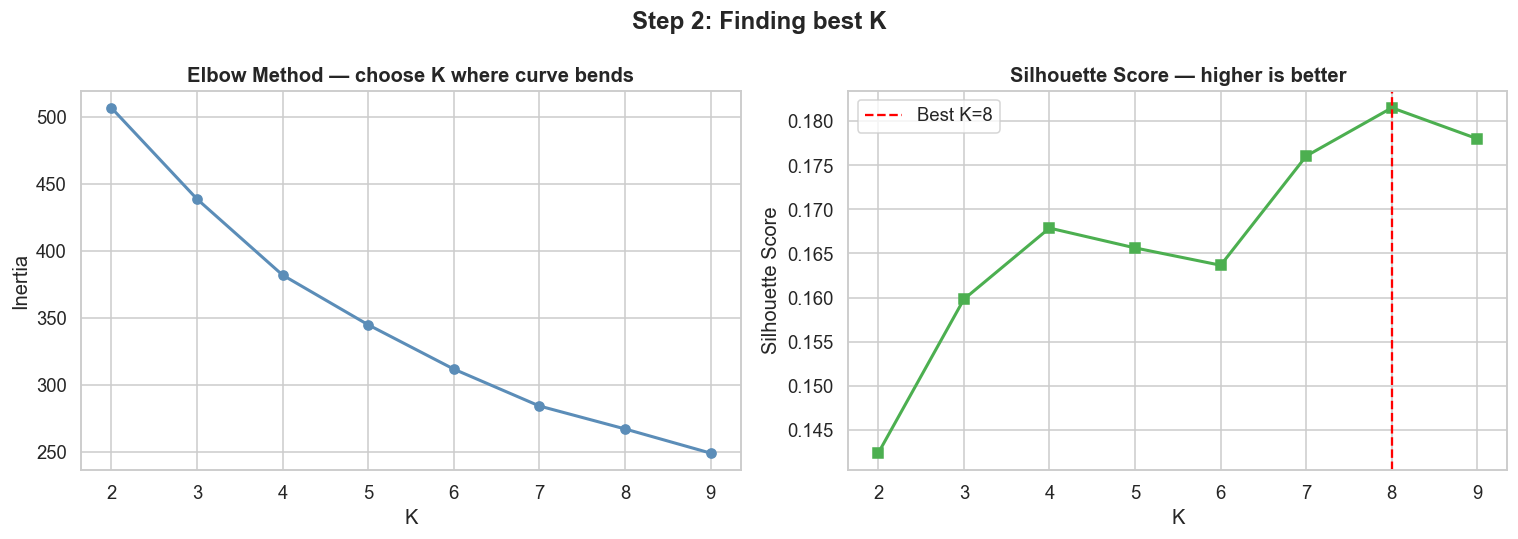

Best K by silhouette: 8


In [13]:
# Step 2 — Normalize + Elbow method
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features[feature_cols])

inertias = []
silhouettes = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, marker='o', color='#5B8DB8', lw=2)
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method — choose K where curve bends', fontweight='bold')

axes[1].plot(K_range, silhouettes, marker='s', color='#4CAF50', lw=2)
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score — higher is better', fontweight='bold')

best_k = K_range[np.argmax(silhouettes)]
axes[1].axvline(best_k, color='red', lw=1.5, linestyle='--', label=f'Best K={best_k}')
axes[1].legend()

plt.suptitle('Step 2: Finding best K', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Best K by silhouette: {best_k}")


In [14]:
# Step 3 — Apply K-Means with best K
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
features['cluster'] = km_final.fit_predict(X_scaled)

print("Companies per cluster:")
print(features['cluster'].value_counts().sort_index())
print("\nCluster vs actual sector:")
display(pd.crosstab(features['cluster'], features['sector']))

Companies per cluster:
cluster
0    13
1    12
2    18
3    11
4    17
5    12
6     9
7     8
Name: count, dtype: int64

Cluster vs actual sector:


sector,Auto,Banking,Energy,FMCG,IT,Pharma
cluster,,,,,,
0,1,0,3,4,3,2
1,0,4,2,1,1,4
2,0,4,4,2,2,6
3,2,2,4,0,0,3
4,8,2,2,1,1,3
5,0,3,1,2,3,3
6,4,2,1,1,0,1
7,2,2,0,0,1,3


Variance explained: PC1=23.0%, PC2=18.9%


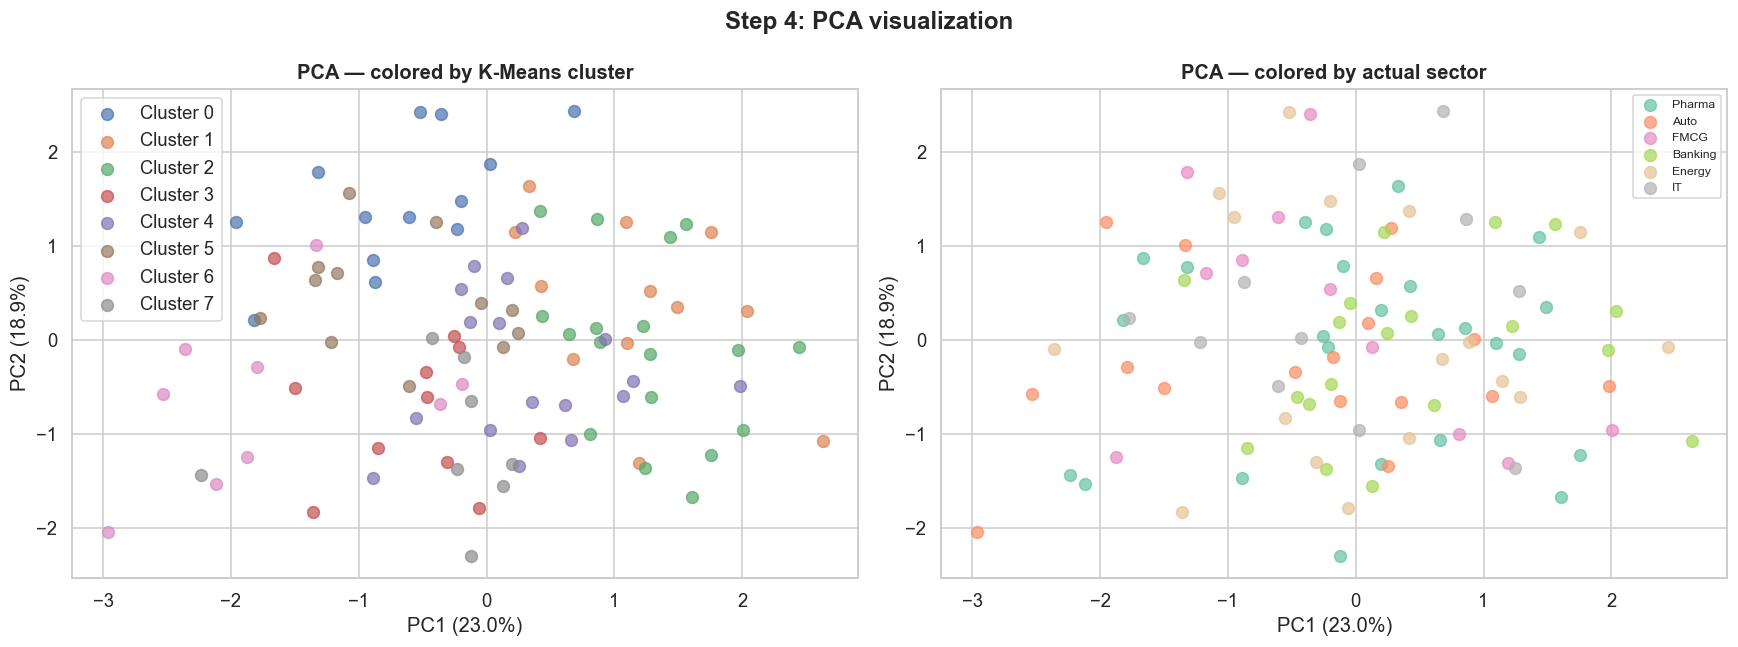

In [15]:
# Step 4 — PCA to 2D + scatter plot
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

features['pca_x'] = X_pca[:, 0]
features['pca_y'] = X_pca[:, 1]

print(f"Variance explained: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, PC2={pca.explained_variance_ratio_[1]*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# By cluster
for cluster in sorted(features['cluster'].unique()):
    mask = features['cluster'] == cluster
    axes[0].scatter(features[mask]['pca_x'], features[mask]['pca_y'],
                    label=f'Cluster {cluster}', s=60, alpha=0.7)
axes[0].set_title('PCA — colored by K-Means cluster', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend()

# By actual sector
sectors = features['sector'].unique()
colors = plt.cm.Set2(np.linspace(0, 1, len(sectors)))
for sec, col in zip(sectors, colors):
    mask = features['sector'] == sec
    axes[1].scatter(features[mask]['pca_x'], features[mask]['pca_y'],
                    label=sec, s=60, alpha=0.7, color=col)
axes[1].set_title('PCA — colored by actual sector', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend(fontsize=8)

plt.suptitle('Step 4: PCA visualization', fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# Step 5 — Label each cluster based on avg metrics
cluster_profiles = features.groupby('cluster')[feature_cols].mean().round(2)
print("Cluster profiles:")
display(cluster_profiles)

# Auto label clusters
def label_cluster(row):
    if row['avg_growth_3y'] > 15 and row['avg_de'] < 1:
        return 'High Growth, Low Debt'
    elif row['avg_dividend'] > 30 and row['avg_growth_3y'] < 10:
        return 'Stable Dividend, Moderate Growth'
    elif row['avg_de'] > 1.5:
        return 'High Leverage'
    elif row['avg_opm'] > 20:
        return 'High Margin'
    else:
        return 'Balanced'

cluster_labels = cluster_profiles.apply(label_cluster, axis=1)
features['cluster_label'] = features['cluster'].map(cluster_labels)

print("\nCluster labels:")
print(cluster_labels)
print("\nCompanies per cluster label:")
print(features['cluster_label'].value_counts())

Cluster profiles:


,avg_opm,roe_percentage,avg_growth_3y,avg_de,avg_ccr,avg_dividend
cluster,,,,,,
0,21.24,29.98,23.05,1.24,2.61,24.46
1,19.89,11.85,15.39,1.71,2.38,24.21
2,19.81,25.61,4.05,1.81,2.86,27.46
3,18.17,12.66,20.06,1.38,3.11,34.74
4,20.32,14.57,3.12,1.27,3.17,28.68
5,22.79,29.92,13.84,1.49,2.76,36.59
6,19.98,22.70,13.61,1.35,12.65,31.07
7,15.56,33.53,9.53,1.47,4.17,31.74



Cluster labels:
cluster
0                         High Margin
1                       High Leverage
2                       High Leverage
3                            Balanced
4                         High Margin
5                         High Margin
6                            Balanced
7    Stable Dividend, Moderate Growth
dtype: str

Companies per cluster label:
cluster_label
High Margin                         42
High Leverage                       30
Balanced                            20
Stable Dividend, Moderate Growth     8
Name: count, dtype: int64


In [17]:
# DBSCAN — alternative clustering
dbscan = DBSCAN(eps=1.5, min_samples=5)
features['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print(f"DBSCAN clusters found: {features['dbscan_cluster'].nunique()}")
print(f"Noise points (-1)    : {(features['dbscan_cluster'] == -1).sum()}")
print(features['dbscan_cluster'].value_counts())

DBSCAN clusters found: 3
Noise points (-1)    : 51
dbscan_cluster
-1    51
 0    42
 1     7
Name: count, dtype: int64


In [18]:
# Step 6 — Export cluster mapping
os.makedirs('../data/processed', exist_ok=True)
features[['company_id', 'company_name', 'sector', 'cluster', 'cluster_label', 'dbscan_cluster']].to_csv(
    '../data/processed/cluster_mapping.csv', index=False
)
print("✅ Exported to data/processed/cluster_mapping.csv")

print("\n" + "="*60)
print("NOTEBOOK 4 SUMMARY — Sector Clustering")
print("="*60)
print(f"K-Means clusters : {best_k}")
print(f"DBSCAN clusters  : {features['dbscan_cluster'].nunique()}")
print(f"Variance by PCA  : {sum(pca.explained_variance_ratio_)*100:.1f}%")
print("\n✅ Ready for Notebook 5 — Peer Comparison!")

✅ Exported to data/processed/cluster_mapping.csv

NOTEBOOK 4 SUMMARY — Sector Clustering
K-Means clusters : 8
DBSCAN clusters  : 3
Variance by PCA  : 41.8%

✅ Ready for Notebook 5 — Peer Comparison!
